# Multiple Lr with more than 1 independent features. :

## Here we're using "datasets/economic_index.csv" where:
- We have 2 independent features and one dependent features with Linear relation .
- Thus, it's Multi-LR.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm


In [3]:
df=pd.read_csv("../datasets/economic_index.csv")
df.head()


,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:

print(df.isnull().sum())
print("---------------------------------- ")

print(df.info())

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64
---------------------------------- 
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         24 non-null     int64  
 1   year               24 non-null     int64  
 2   month              24 non-null     int64  
 3   interest_rate      24 non-null     float64
 4   unemployment_rate  24 non-null     float64
 5   index_price        24 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 1.3 KB
None


In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'year', 'month', 'interest_rate', 'unemployment_rate', 'index_price']


In [6]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


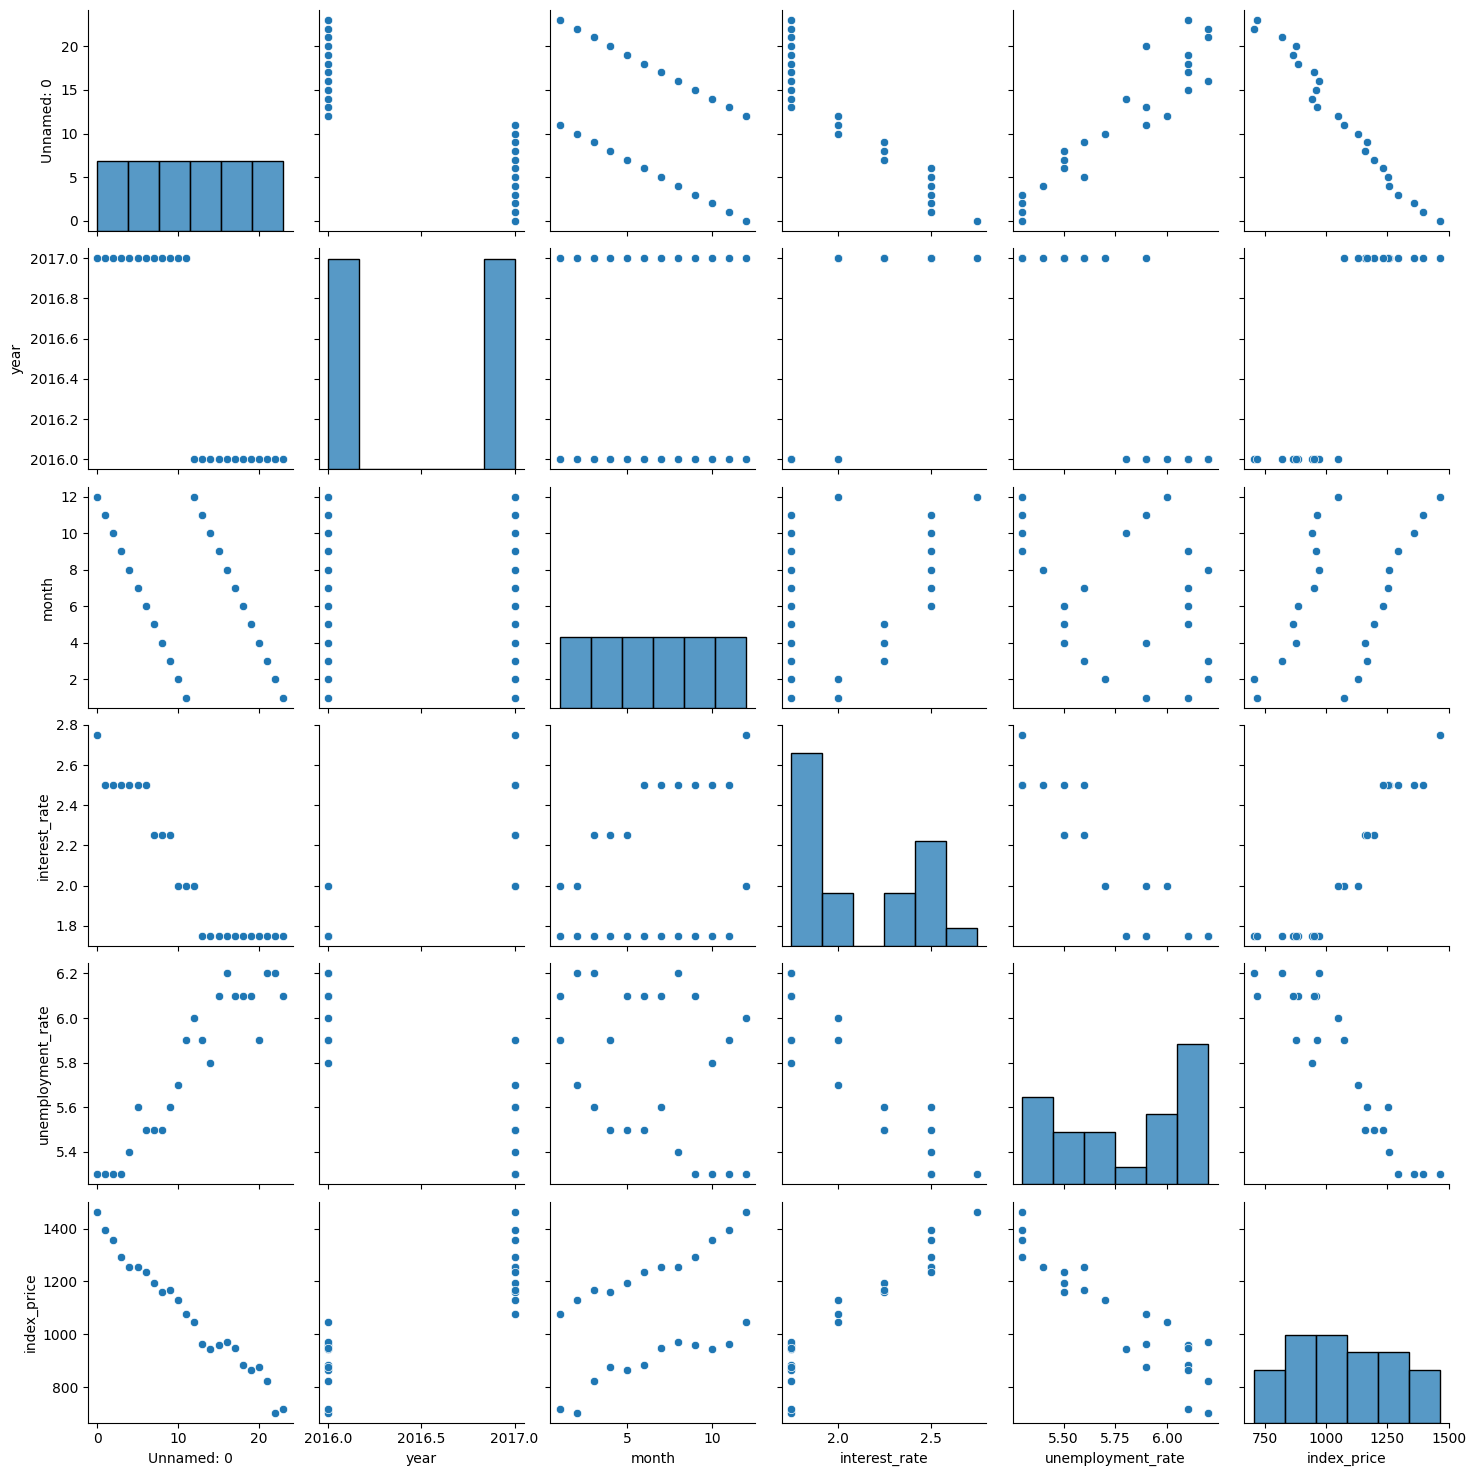

In [7]:
sns.pairplot(df)

In [8]:
df.corr()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-8.667781e-01,-4.986939e-01,-0.934555,0.935300,-0.988246
year,-0.866778,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,-0.498694,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,-0.934555,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,-0.988246,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


Text(0, 0.5, 'berozgari')

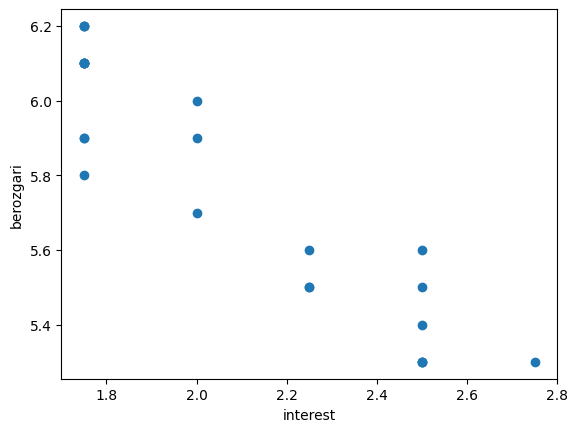

In [9]:

print(plt.scatter(df["interest_rate"], df["unemployment_rate"]))
plt.xlabel("interest")
plt.ylabel("berozgari")


In [10]:
# Printing the Dependent and independent vars.
X = df[['interest_rate', 'unemployment_rate']] # Note the double brackets for 2D array
y = df['index_price']


In [11]:
# train test split :
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [12]:
# Standardization :
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)


Axes(0.125,0.11;0.775x0.77)


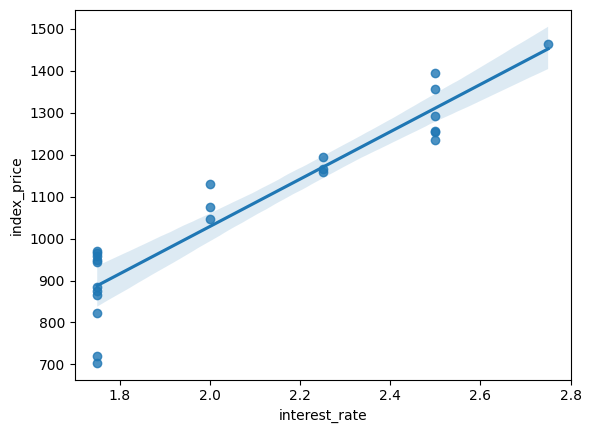

In [13]:
import seaborn as sns

# Fix: Use keyword arguments
print(sns.regplot(x=df["interest_rate"], y=df["index_price"]))



Axes(0.125,0.11;0.775x0.77)


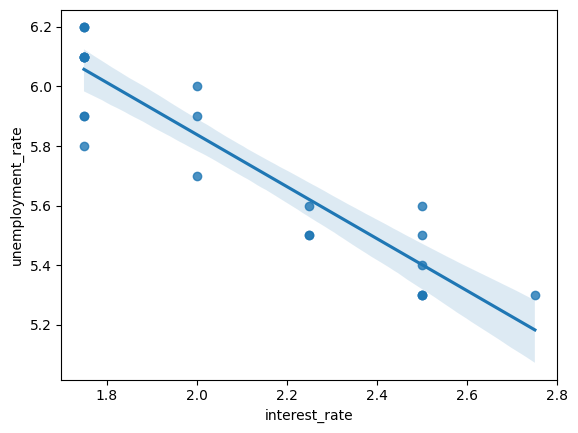

In [14]:
print(sns.regplot(x=df["interest_rate"], y=df["unemployment_rate"]))

In [15]:
from sklearn.linear_model import LinearRegression
regression =LinearRegression()
regression.fit(X_train_scaled, y_train)

print("Coeff:", regression.coef_)
print("Intercept:", regression.intercept_)

Coeff: [  88.27275507 -116.25716066]
Intercept: 1053.4444444444443


# Doing the cross validation of the data for hypertuning of model.

In [16]:
#Cross validation 
from sklearn.model_selection import cross_val_score
validn_score= cross_val_score(regression, X_train, y_train, scoring="neg_mean_squared_error")


### Meaning of the syntax :
- Suppose we have the data of 100 vals of which we use 900 in trian and 100 in test.
- Now using the cross validatoin we can hypertune our model by again splitting the trainig data into training and validation.
- Suppose if we have cv=5 this means we split 900/5 =180
- So, we divide the data into chunks of 180 datasets.
- In the end we take the avg. of all the CVs
- And for good model working the -ve MSE should be close to 0. 

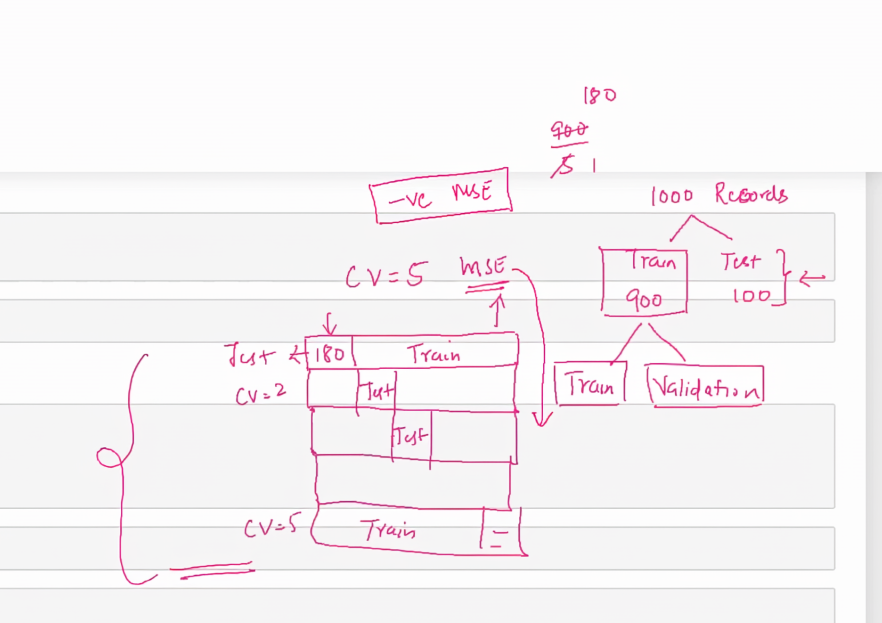

In [17]:
print(validn_score)
print(" ")

print("mean :",np.mean(validn_score))

[-1861.74046551 -8715.8459466  -7707.52362191 -9169.13776461
  -791.32842311]
 
mean : -5649.115244350768


In [18]:
y_pred_scaled= regression.predict(X_test_scaled)
y_pred_= regression.predict(X_test)

print(y_pred_scaled)
print(y_pred_)

[1180.7466813   802.74279699 1379.83457045  838.52599602  973.85313963
 1144.96348227]
[612.64375972 487.12736973 680.03156939 498.75308579 544.07270669
 601.01804366]


e:\AI-ML\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [21]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MSE: ", mse)

# R-sq score:
from sklearn.metrics import r2_score
r_sq=r2_score(y_test, y_pred)
print("R-sq. :", r_sq)

# Adj r-sq value:
adj_r_sq= 1-(1-r_sq)*(len(y_test)-1)/(len(y_test)- X_test.shape[1] -1)
print("Adj R-sq :", adj_r_sq)


RMSE:  90.04758423359621
MAE:  73.80444932337097
MSE:  8108.567426306604
R-sq. : 0.7591371539010257
Adj R-sq : 0.5985619231683761


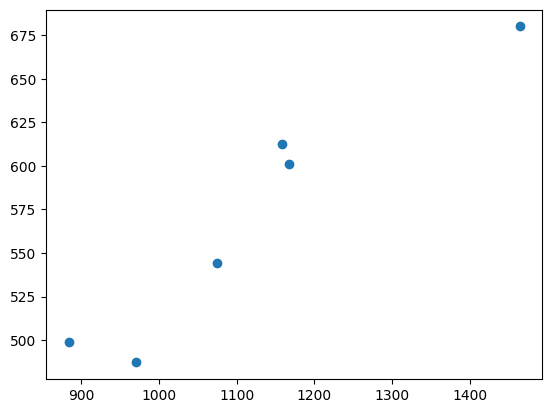

In [25]:
# BFL:
import matplotlib.pyplot as plt
# plt.scatter(X_train, y_train)
plt.scatter(y_test, y_pred_)
# plt.plot(X_train, regression.predict(X_train), color="red")